# Lab 0: Text classification exploration
### COSC 426: Fall 2025, Colgate University

I am not expecting you to come in knowing how to use this notebook. So don't worry or panic if you've never worked with jupyter notebooks before! However, since this is a 400-level class that is designed to encourage independent work, I expect you to look up things you don't understand or know how to do. Don't hesitate to reach out if you are stuck!

## Basic demonstration

This section demonstrates how to load data and access columns in dataframes

In [1]:
# Import relevant packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
toy_preds = pd.read_csv('predictions_toy_gold.txt', sep = '\t') ## loads in data

print(toy_preds.columns) # prints columns

toy_preds.head() ## prints the first 5 rows of the dataframe. Note you don't have to print the last thing in a cell to display it.  

Index(['text', 'gold', 'predicted', 'correct'], dtype='object')


,text,gold,predicted,correct
0,God save the most judgmental creeps,swift,shakespeare,0
1,Who say they want what's best for me,swift,swift,1
2,Sanctimoniously performing soliloquies I'll ne...,swift,swift,1
3,Thinkin' it can change the beat,swift,swift,1
4,Of my heart when he touches me,swift,shakespeare,0


In [14]:
toy_preds['correct'].sum() ## prints the sum of the column "correct"

12

## Evaluate model predictions

In this part, you will evaluate the model predictions from your `predictions.txt`. Concretely, answer the following questions: 

1. What is the average accuracy of the model?
2. If you consider the artists separately, what is the average accuracy for Shakespeare and the average accuracy for Swift?

You can print these numbers (like the sum was printed in the previous cell), or as a bonus, you can look into how you can plot this! 

Hint: If you choose to plot this, `groupby` and `agg` in pandas will be useful!

**Feel free to add as many code and markdown chunks as you would like**

In [22]:
## Add your code here
preds = pd.read_csv('predictions.txt', sep = '\t') ## loads in data

## Overall accuracy
accuracy = preds['correct'].sum() / len(preds) 
print(f'Accuracy: {accuracy}') 

## Artist-specific accuracy
Shakespeare_accuracy = preds[preds['gold'] == 'shakespeare']['correct'].sum() / len(preds[preds['gold'] == 'shakespeare'])
Swift_accuracy = preds[preds['gold'] == 'swift']['correct'].sum() / len(preds[preds['gold'] == 'swift'])
print(f'Shakespeare Accuracy: {Shakespeare_accuracy}')
print(f'Swift Accuracy: {Swift_accuracy}')

Accuracy: 0.8404509736932012
Shakespeare Accuracy: 0.8289773343455157
Swift Accuracy: 0.8829915560916767


The average accuracy of the model is 84.05% with 82.90% for Shakespeare and 88.30% for Swift.

In [25]:
artist_stats = preds.groupby('gold').agg({
    'correct': ['count', 'sum', 'mean'],
    'predicted': 'count'
}).round(4)

artist_stats.columns = ['total_samples', 'correct_predictions', 'accuracy', 'total_predictions']
artist_stats = artist_stats.drop('total_predictions', axis=1)

print("Artist-specific Statistics:")
print(artist_stats)

Artist-specific Statistics:
             total_samples  correct_predictions  accuracy
gold                                                     
shakespeare           9221                 7644     0.829
swift                 2487                 2196     0.883


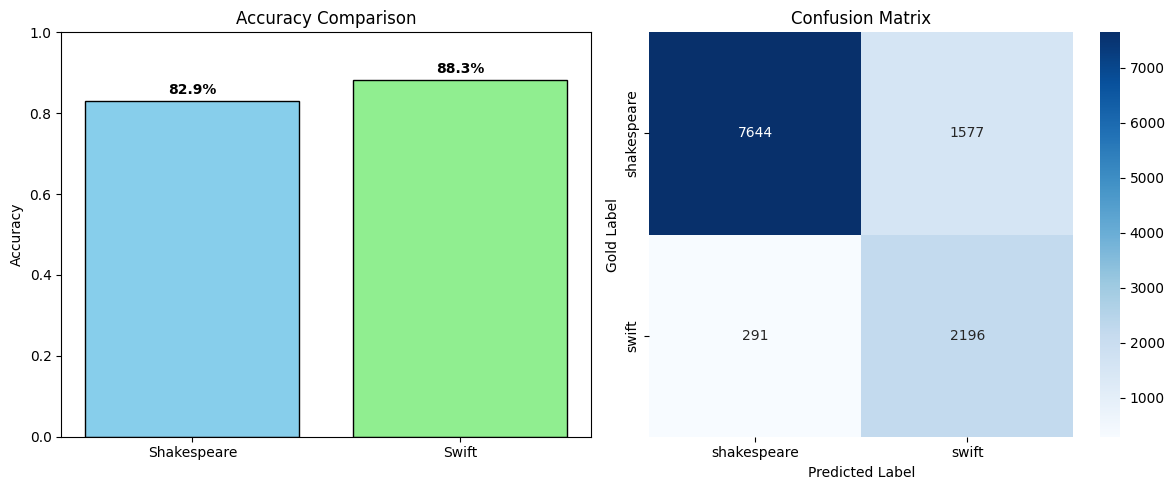

In [40]:
## Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

artists = ['Shakespeare', 'Swift']
accuracies = [Shakespeare_accuracy, Swift_accuracy]
colors = ['skyblue', 'lightgreen']

bars = ax1.bar(artists, accuracies, color=colors, edgecolor='black')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')
    
confusion_data = pd.crosstab(preds['gold'], preds['predicted'])
sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Confusion Matrix')
ax2.set_ylabel('Gold Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()